In [18]:
import pandas as pd
import numpy as np
import re
import nltk
import pytz
from datetime import datetime
from nltk.corpus import stopwords
from collections import Counter
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\huber\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
df = pd.read_csv('english_bg3_reviews.csv', delimiter=';')
print(df["review_id"].is_unique)
print(df.info())

True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100098 entries, 0 to 100097
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   review_id          100098 non-null  int64 
 1   review             99620 non-null   object
 2   voted_up           100098 non-null  bool  
 3   timestamp_created  100098 non-null  int64 
 4   author_steamid     100098 non-null  int64 
dtypes: bool(1), int64(3), object(1)
memory usage: 3.2+ MB
None


In [22]:
df.head(8)

,review_id,review,voted_up,timestamp_created,author_steamid
0,209492575,very good game :),True,1763408982,76561198079322180
1,209492181,"Yes, it is as good as everyone says it is. Buy...",True,1763408630,76561198451366797
2,209491639,gud,True,1763408133,76561198259769014
3,209490463,The greatest game of all time. It simply is. \r\n,True,1763407044,76561198842852247
4,209488275,The dude trying to bite me at night was messed...,True,1763405137,76561198335095296
5,209488128,"This is probably a great solo game, but my hop...",False,1763405008,76561198031957731
6,209487979,One of the best RPG's of the last decade,True,1763404876,76561198140742800
7,209484454,good game,True,1763401645,76561199237561360


In [3]:
print(df.isnull().sum())
df.nunique()


review_id              0
review               478
voted_up               0
timestamp_created      0
author_steamid         0
dtype: int64


review_id            100098
review                81590
voted_up                  2
timestamp_created     99947
author_steamid       100098
dtype: int64

In [4]:
# konwersja UNIX
def to_datetime_series(s):
    s = pd.to_numeric(s, errors='coerce')
    if s.dropna().empty:
        return pd.to_datetime(s, errors='coerce')
    maxv = int(s.dropna().abs().max())
    unit = 's' if maxv < 1e11 else 'ms'
    return pd.to_datetime(s, unit=unit, utc=True)
df['date_str'] = to_datetime_series(df.get('timestamp_created', pd.Series(dtype='float'))).dt.tz_convert('Europe/Warsaw').dt.strftime('%Y-%m-%d %H:%M:%S')
df.head()


,review_id,review,voted_up,timestamp_created,author_steamid,date_str
0,209492575,very good game :),True,1763408982,76561198079322180,2025-11-17 20:49:42
1,209492181,"Yes, it is as good as everyone says it is. Buy...",True,1763408630,76561198451366797,2025-11-17 20:43:50
2,209491639,gud,True,1763408133,76561198259769014,2025-11-17 20:35:33
3,209490463,The greatest game of all time. It simply is. \r\n,True,1763407044,76561198842852247,2025-11-17 20:17:24
4,209488275,The dude trying to bite me at night was messed...,True,1763405137,76561198335095296,2025-11-17 19:45:37


In [5]:
df = df.drop_duplicates(subset=['review'])  
df = df.dropna(subset=['review'])

# dlugosc recenzji (liczba znakow i liczba slow)

df['review_length'] = df['review'].apply(lambda x: len(str(x)))
df['review_word_count'] = df['review'].apply(lambda x: len(str(x).split()))

print(df['review_length'].describe())
print(df['review_word_count'].describe())

count    81590.000000
mean       203.140838
std        485.268416
min          1.000000
25%         29.000000
50%         68.000000
75%        177.000000
max       8000.000000
Name: review_length, dtype: float64
count    81590.000000
mean        36.842358
std         85.844015
min          0.000000
25%          5.000000
50%         13.000000
75%         33.000000
max       1506.000000
Name: review_word_count, dtype: float64


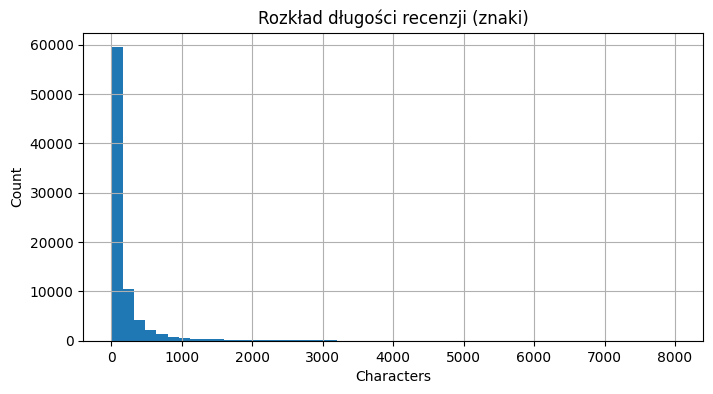

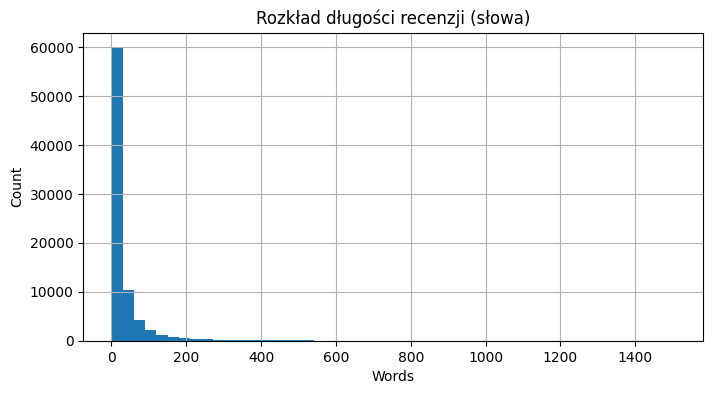

In [6]:
# Wizualizacje EDA
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
df['review_length'].hist(bins=50)
plt.title('Rozkład długości recenzji (znaki)')
plt.xlabel('Characters'); plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8,4))
df['review_word_count'].hist(bins=50)
plt.title('Rozkład długości recenzji (słowa)')
plt.xlabel('Words'); plt.ylabel('Count')
plt.show()

voted_up
True     78019
False     3571
Name: count, dtype: int64


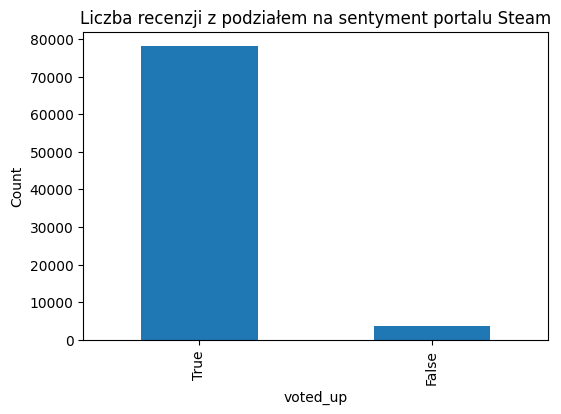

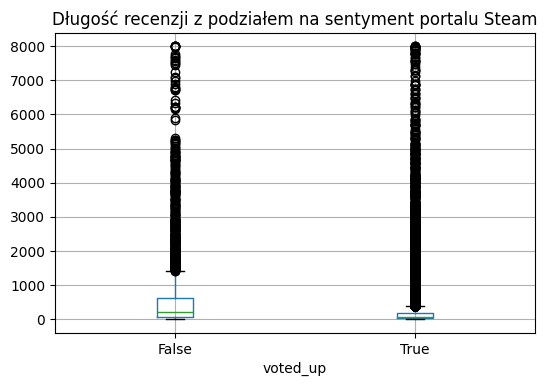

In [7]:
# Procent pozytywnych/negatywnych
if 'voted_up' in df.columns:
    counts = df['voted_up'].value_counts(dropna=False)
    print(counts)
    counts.plot(kind='bar', figsize=(6,4), title='Liczba recenzji z podziałem na sentyment portalu Steam')
    plt.xlabel('voted_up'); plt.ylabel('Count'); plt.show()

    # Boxplot długości recenzji według voted_up
    df.boxplot(column='review_length', by='voted_up', figsize=(6,4))
    plt.title('Długość recenzji z podziałem na sentyment portalu Steam'); plt.suptitle(''); plt.show()

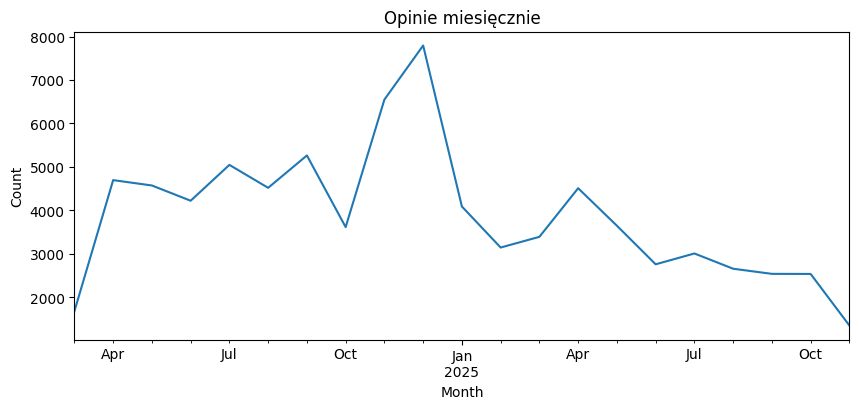

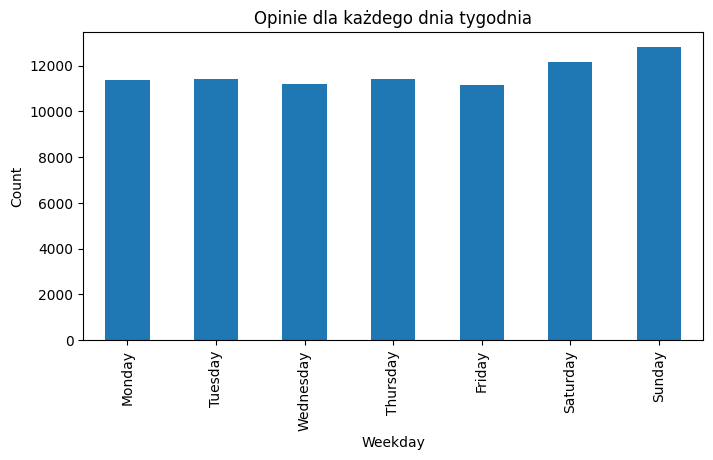

In [8]:
# rozkład w czasie
df['date_dt'] = pd.to_datetime(df['date_str'], errors='coerce')
try:
    df['date_dt'] = df['date_dt'].dt.tz_localize('Europe/Warsaw')
except Exception:
    pass

# miesięcznie
monthly = df.set_index('date_dt').resample('ME').size()
monthly.plot(figsize=(10,4), title='Opinie miesięcznie')
plt.xlabel('Month'); plt.ylabel('Count'); plt.show()

# dzien tygodnia
df['weekday'] = df['date_dt'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_counts = df['weekday'].value_counts().reindex(order).fillna(0)
weekday_counts.plot(kind='bar', figsize=(8,4), title='Opinie dla każdego dnia tygodnia')
plt.xlabel('Weekday'); plt.ylabel('Count'); plt.show()

In [9]:
# czyszczenie tekstu

def clean_reviews(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)

    return text

df['clean_review'] = df['review'].apply(clean_reviews)

df['clean_review']

0                                           very good game 
1           yes it is as good as everyone says it is buy it
2                                                       gud
3               the greatest game of all time it simply is 
4         the dude trying to bite me at night was messed...
                                ...                        
100093    dnd and fun pls give mods so i can play other ...
100094                                qsaveqload simulator 
100095                       what else its a great game buy
100096    first playthrough was rough and i couldnt look...
100097    ive completed the game only one time through a...
Name: clean_review, Length: 81590, dtype: object

In [10]:
# Usuwanie stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

df['no_stopwords'] = df['clean_review'].apply(remove_stopwords)


Top 20 words: [('game', 76297), ('like', 15066), ('play', 14986), ('one', 13007), ('story', 12832), ('games', 12744), ('best', 12440), ('good', 12358), ('time', 11014), ('played', 10915), ('great', 9867), ('love', 9865), ('ever', 9242), ('fun', 8644), ('hours', 8396), ('ive', 8185), ('characters', 8136), ('even', 7906), ('get', 7883), ('much', 7740)]


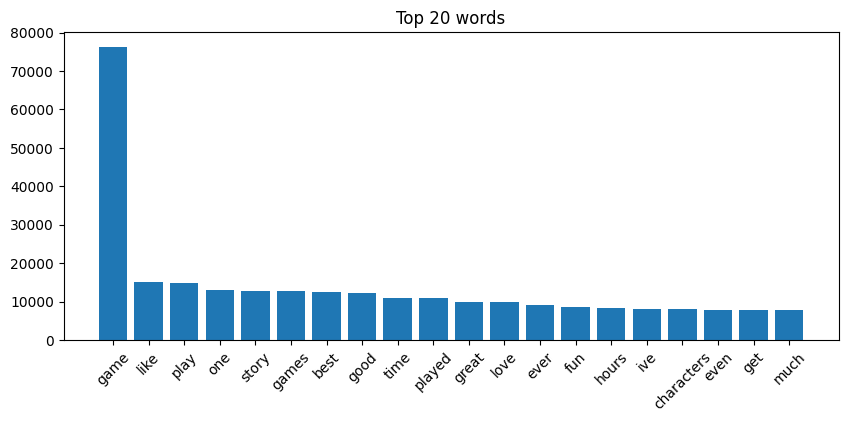

Shortest reviews (sample):
         review  review_word_count
1706       \r\n                  0
5405                             0
12143                            0
12931        \n                  0
14641  \r\n\r\n                  0
Longest reviews (sample):
                                                  review  review_word_count
54614  not THAT great\n\nif you have something to do ...               1506
79734  I'm kinda sorry to say this, but game is overr...               1481
60933  Baldur's Gate 3 is a remarkable achievement in...               1472
35298  LARIAN STUDIOS ARE MORON DEVELOPERS WHO DON'T ...               1464
85050  First of all, in my opinion the game is good, ...               1454


In [11]:
# Top words
text_col = 'no_stopwords' if 'no_stopwords' in df.columns else ('review' if 'review' in df.columns else None)
if text_col is None:
    print("Brak kolumny z tekstem do analizy (no_stopwords/review).")
else:
    joined = ' '.join(df[text_col].dropna().astype(str))
    if not joined.strip():
        print(f"Kolumna '{text_col}' nie zawiera tekstu.")
    else:
        all_words = joined.split()
        common = Counter(all_words).most_common(20)
        print("Top 20 words:", common)
        words, freqs = zip(*common) if common else ([],[])
        plt.figure(figsize=(10,4))
        plt.bar(words, freqs)
        plt.xticks(rotation=45); plt.title('Top 20 words'); plt.show()

# Przykłady krótkich / długich recenzji (kontrolny podgląd)
print("Shortest reviews (sample):")
print(df.nsmallest(5, 'review_word_count')[['review','review_word_count']])
print("Longest reviews (sample):")
print(df.nlargest(5, 'review_word_count')[['review','review_word_count']])

In [12]:
# ile procent negatywnych opinii ma cały zbiór
positive_reviews = df[df['voted_up'] == True]
negative_reviews = df[df['voted_up'] == False]

print(f"positive reviews: {len(positive_reviews)}")
print(f"negative reviews: {len(negative_reviews)}")
print(f"negative to positive ratio: {(len(negative_reviews) / len(positive_reviews)) * 100 }")

positive reviews: 78019
negative reviews: 3571
negative to positive ratio: 4.577090195977903


In [13]:
# short reviews - less than 4 words
short_reviews = df[df['review_word_count'] < 4]
print("Bardzo krótkie recenzje:")
print(short_reviews[['review', 'review_word_count']])

# long reviews - more than 150 words
long_reviews = df[df['review_word_count'] > 150]
print("Bardzo długie recenzje:")
print(long_reviews[['review', 'review_word_count']])


Bardzo krótkie recenzje:
                      review  review_word_count
2                        gud                  1
7                  good game                  2
14            love this game                  3
15      Sword meets sorcery!                  3
23                      Good                  1
...                      ...                ...
100076       I like ROCKS!!!                  3
100079   Pure masterpiece!!!                  2
100082              Good DnD                  2
100085        RPGs benchmark                  2
100090          good. i like                  3

[11962 rows x 2 columns]
Bardzo długie recenzje:
                                                   review  review_word_count
81      Baldur's Gate 3 is, in my opinion, the best RP...                319
115     I had high expectations based on the universal...                338
126     Baldurs Gate 3 is THE BEST RPG I've ever playe...                266
194     So I've just finished watching 40

In [14]:
df.head()

,review_id,review,voted_up,timestamp_created,author_steamid,date_str,review_length,review_word_count,date_dt,weekday,clean_review,no_stopwords
0,209492575,very good game :),True,1763408982,76561198079322180,2025-11-17 20:49:42,17,4,2025-11-17 20:49:42,Monday,very good game,good game
1,209492181,"Yes, it is as good as everyone says it is. Buy...",True,1763408630,76561198451366797,2025-11-17 20:43:50,50,12,2025-11-17 20:43:50,Monday,yes it is as good as everyone says it is buy it,yes good everyone says buy
2,209491639,gud,True,1763408133,76561198259769014,2025-11-17 20:35:33,3,1,2025-11-17 20:35:33,Monday,gud,gud
3,209490463,The greatest game of all time. It simply is. \r\n,True,1763407044,76561198842852247,2025-11-17 20:17:24,47,9,2025-11-17 20:17:24,Monday,the greatest game of all time it simply is,greatest game time simply
4,209488275,The dude trying to bite me at night was messed...,True,1763405137,76561198335095296,2025-11-17 19:45:37,59,12,2025-11-17 19:45:37,Monday,the dude trying to bite me at night was messed...,dude trying bite night messed lfmao


In [15]:
#finalne czyszczenie kodu - usuwanie niepotrzebnych do dalszej pracy kolumn
df.drop(columns=['timestamp_created', 'weekday', 'no_stopwords', 'date_dt'], inplace=True)
df.head()

,review_id,review,voted_up,author_steamid,date_str,review_length,review_word_count,clean_review
0,209492575,very good game :),True,76561198079322180,2025-11-17 20:49:42,17,4,very good game
1,209492181,"Yes, it is as good as everyone says it is. Buy...",True,76561198451366797,2025-11-17 20:43:50,50,12,yes it is as good as everyone says it is buy it
2,209491639,gud,True,76561198259769014,2025-11-17 20:35:33,3,1,gud
3,209490463,The greatest game of all time. It simply is. \r\n,True,76561198842852247,2025-11-17 20:17:24,47,9,the greatest game of all time it simply is
4,209488275,The dude trying to bite me at night was messed...,True,76561198335095296,2025-11-17 19:45:37,59,12,the dude trying to bite me at night was messed...


In [16]:
#zapis "czystych" recenzji
df.to_csv('english_bg3_reviews_cleaned.csv', sep=';', index=False, encoding='utf-8')
print(len(df))

81590


In [17]:
df_sprawdzenie = pd.read_csv('english_bg3_reviews_cleaned.csv', delimiter=';', encoding='utf-8')
print(df_sprawdzenie['review_id'].nunique())

81590
